# MACHINE LEARNING PROJECT

> Streaming Multi-Modal Adaptive Learning System with Concept Drift & Self-Evaluation



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    log_loss,
    f1_score
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

from scipy.stats import skew, kurtosis, entropy
from scipy.ndimage import rotate, shift, sobel

from tensorflow.keras.datasets import mnist

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [3]:
def extract_advanced_features(images):
    features = []

    for img in images:
        flat = img.flatten().astype(np.float64)

        # Basic stats
        mean_val = np.mean(flat)
        var_val = np.var(flat)
        skew_val = skew(flat) if var_val > 1e-8 else 0.0
        kurt_val = kurtosis(flat) if var_val > 1e-8 else 0.0

        # Entropy
        total = np.sum(flat)
        if total <= 1e-8:
            ent = 0.0
        else:
            prob_dist = flat / total
            prob_dist = np.clip(prob_dist, 1e-12, 1)
            ent = entropy(prob_dist)

        # Edge density
        edge_density = np.mean(np.abs(np.diff(flat)))

        # Local contrast (3x3 subsampling)
        local_contrast = np.std(img[::3, ::3])

        # Sobel edges
        sx = sobel(img, axis=0)
        sy = sobel(img, axis=1)
        sobel_mag = np.hypot(sx, sy)
        sobel_mean = np.mean(sobel_mag)
        sobel_std = np.std(sobel_mag)

        # Symmetry
        h_sym = np.mean(img == np.flip(img, axis=0))  # horizontal symmetry
        v_sym = np.mean(img == np.flip(img, axis=1))  # vertical symmetry

        # Central moments (2nd order)
        x, y = np.meshgrid(np.arange(img.shape[1]), np.arange(img.shape[0]))
        m00 = np.sum(img)
        if m00 == 0:
            mu20 = mu02 = 0.0
        else:
            x_c = np.sum(x * img) / m00
            y_c = np.sum(y * img) / m00
            mu20 = np.sum(((x - x_c) ** 2) * img) / m00
            mu02 = np.sum(((y - y_c) ** 2) * img) / m00

        # Combine all features
        features.append([
            mean_val,
            var_val,
            skew_val,
            kurt_val,
            ent,
            edge_density,
            local_contrast,
            sobel_mean,
            sobel_std,
            h_sym,
            v_sym,
            mu20,
            mu02
        ])

    return np.nan_to_num(np.array(features))


In [4]:
from scipy.ndimage import rotate, shift
import numpy as np

def augment_batch(images):
    augmented = []

    for img in images:
        # Small rotation
        img = rotate(img, angle=np.random.uniform(-10, 10), reshape=False)

        # Small horizontal + vertical shift
        img = shift(img, shift=(np.random.uniform(-2, 2), np.random.uniform(-2, 2)))

        # Brightness scaling (slightly)
        img = img * np.random.uniform(0.9, 1.1)

        # Gaussian noise (light)
        noise = np.random.normal(0, 5, img.shape)
        img = img + noise

        # Clip pixels
        img = np.clip(img, 0, 255)

        augmented.append(img)

    return np.array(augmented, dtype=np.float32)


In [5]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def prepare_multimodal(images, scaler_flat=None, scaler_stats=None):
    # Clip to safe pixel range
    images = np.clip(images, 0, 255)

    # Flatten + cast
    flat = images.reshape(len(images), -1).astype(np.float32)

    # Extract advanced features
    stats = extract_advanced_features(images).astype(np.float32)

    # Clip extreme values in stats
    stats = np.clip(stats, -1e6, 1e6)
    stats = np.nan_to_num(stats, nan=0.0, posinf=1e6, neginf=-1e6)

    # Scale flat pixels
    if scaler_flat is None:
        scaler_flat = StandardScaler()
        flat = scaler_flat.fit_transform(flat)
    else:
        flat = scaler_flat.transform(flat)

    # Scale stats
    if scaler_stats is None:
        scaler_stats = StandardScaler()
        stats = scaler_stats.fit_transform(stats)
    else:
        stats = scaler_stats.transform(stats)

    # Combine features
    combined = np.hstack([flat, stats])

    return combined, scaler_flat, scaler_stats


In [6]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Mask for non-9s
mask = y_train != 9
non_nine_indices = np.where(mask)[0]

# Randomly sample 30% of 9s
nine_indices = np.where(y_train == 9)[0]
reduced_nines = np.random.choice(
    nine_indices,
    int(len(nine_indices) * 0.3),
    replace=False
)

# Combine non-9s and reduced 9s
final_indices = np.concatenate([non_nine_indices, reduced_nines])

# Shuffle final indices
np.random.shuffle(final_indices)

# Apply to X_train and y_train
X_train = X_train[final_indices]
y_train = y_train[final_indices]


In [7]:
from sklearn.linear_model import SGDClassifier
import numpy as np

classes = np.unique(y_train)

# SGDClassifier for raw pixels
image_model = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    tol=1e-3,
    eta0=0.01,
    learning_rate="constant",
    random_state=42
)

# SGDClassifier for multimodal features
multi_model = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    tol=1e-3,
    alpha=0.001,  # Increased regularization
    eta0=0.01,
    learning_rate="adaptive", # Changed to adaptive
    random_state=42
)

# SGDClassifier for augmented images
aug_model = SGDClassifier(
    loss="log_loss",
    max_iter=1000,
    tol=1e-3,
    eta0=0.01,
    learning_rate="constant",
    random_state=42
)


In [8]:
batch_size = 4000

scaler_image = StandardScaler()

scaler_multi = StandardScaler()


acc_log = []

loss_log = []

drift_scores = []

confidence_log = []


# Fit scalers once

scaler_image.fit(X_train.reshape(len(X_train), -1))

X_train_multi, scaler_multi_flat, scaler_multi_stats = prepare_multimodal(X_train)

scaler_multi.fit(X_train_multi)

X_test_multi, _, _ = prepare_multimodal(X_test, scaler_multi_flat, scaler_multi_stats)


for batch_num, i in enumerate(range(0, len(X_train), batch_size)):


    X_batch = X_train[i:i+batch_size].copy()

    y_batch = y_train[i:i+batch_size].copy()


    # --- Concept Drift after batch 5 ---

    if batch_num >= 5:

        X_batch = X_batch + np.random.normal(0, 40, X_batch.shape)

        X_batch = X_batch * 0.7

        X_batch = np.clip(X_batch, 0, 255)  # prevent overflow


        flip_mask = np.random.rand(len(y_batch)) < 0.1

        y_batch[flip_mask] = np.random.randint(0, 10, np.sum(flip_mask))


    # --- Augmented version ---

    X_aug = augment_batch(X_batch)


    # --- Prepare features ---

    X_img = scaler_image.transform(X_batch.reshape(len(X_batch), -1))

    X_multi = scaler_multi.transform(prepare_multimodal(X_batch, scaler_multi_flat, scaler_multi_stats)[0])

    X_aug_multi = scaler_multi.transform(prepare_multimodal(X_aug, scaler_multi_flat, scaler_multi_stats)[0])


    # --- Adaptive LR decay ---

    lr = max(0.001, 0.01 / (1 + 0.1 * batch_num))

    image_model.set_params(eta0=lr)

    multi_model.set_params(eta0=lr)

    aug_model.set_params(eta0=lr)


    # --- Partial fit ---

    image_model.partial_fit(X_img, y_batch, classes=classes)

    multi_model.partial_fit(X_multi, y_batch, classes=classes)

    aug_model.partial_fit(X_aug_multi, y_batch, classes=classes)


    # --- Evaluation ---

    y_pred = multi_model.predict(X_test_multi)

    y_proba = multi_model.predict_proba(X_test_multi)

    y_proba = np.nan_to_num(y_proba)

    y_proba = np.clip(y_proba, 1e-15, 1 - 1e-15)


    acc = accuracy_score(y_test, y_pred)

    loss = log_loss(y_test, y_proba)

    drift_score = abs(acc - acc_log[-1]) if acc_log else 0

    confidence = np.mean(np.max(y_proba, axis=1))


    acc_log.append(acc)

    loss_log.append(loss)

    drift_scores.append(drift_score)

    confidence_log.append(confidence)


    print(f"Batch {batch_num+1} | Acc: {acc:.4f} | Loss: {loss:.4f} | Drift: {drift_score:.4f}")

Batch 1 | Acc: 0.8235 | Loss: 0.8196 | Drift: 0.0000
Batch 2 | Acc: 0.8757 | Loss: 0.6179 | Drift: 0.0522
Batch 3 | Acc: 0.8692 | Loss: 0.5746 | Drift: 0.0065
Batch 4 | Acc: 0.8876 | Loss: 0.5219 | Drift: 0.0184
Batch 5 | Acc: 0.8967 | Loss: 0.4806 | Drift: 0.0091
Batch 6 | Acc: 0.6895 | Loss: 1.5377 | Drift: 0.2072
Batch 7 | Acc: 0.6876 | Loss: 1.5853 | Drift: 0.0019
Batch 8 | Acc: 0.6858 | Loss: 1.6109 | Drift: 0.0018
Batch 9 | Acc: 0.6867 | Loss: 1.6362 | Drift: 0.0009
Batch 10 | Acc: 0.6864 | Loss: 1.6427 | Drift: 0.0003
Batch 11 | Acc: 0.6841 | Loss: 1.6457 | Drift: 0.0023
Batch 12 | Acc: 0.6846 | Loss: 1.6431 | Drift: 0.0005
Batch 13 | Acc: 0.6839 | Loss: 1.6507 | Drift: 0.0007
Batch 14 | Acc: 0.6845 | Loss: 1.6417 | Drift: 0.0006


In [9]:
    # Prepare training features safely
X_train_multi, _, _ = prepare_multimodal(X_train, scaler_multi_flat, scaler_multi_stats)
X_train_multi = scaler_multi.transform(X_train_multi)

# Prepare test features (already precomputed)
X_test_multi = scaler_multi.transform(X_test_multi)

# Compute accuracies
train_acc = multi_model.score(X_train_multi, y_train)
test_acc = multi_model.score(X_test_multi, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Generalization Gap:", train_acc - test_acc)


Train Accuracy: 0.7254589415241336
Test Accuracy: 0.6845
Generalization Gap: 0.040958941524133596


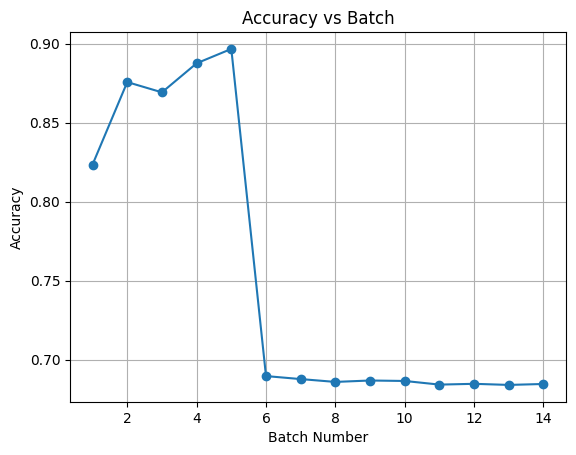

In [10]:
import matplotlib.pyplot as plt

batches = range(1, len(acc_log) + 1)

plt.figure()
plt.plot(batches, acc_log, marker='o')
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Batch")
plt.grid(True)
plt.show()

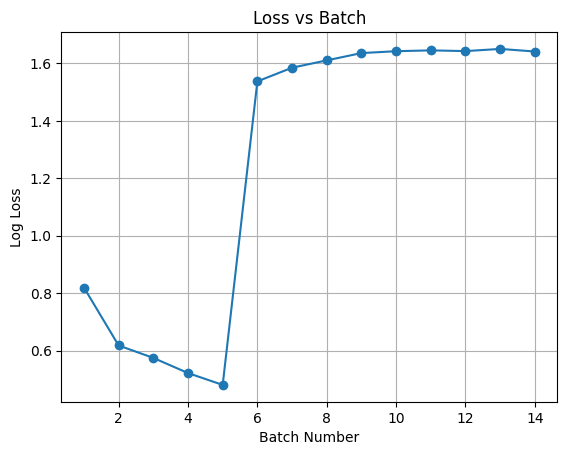

In [11]:
plt.figure()
plt.plot(batches, loss_log, marker='o')
plt.xlabel("Batch Number")
plt.ylabel("Log Loss")
plt.title("Loss vs Batch")
plt.grid(True)
plt.show()

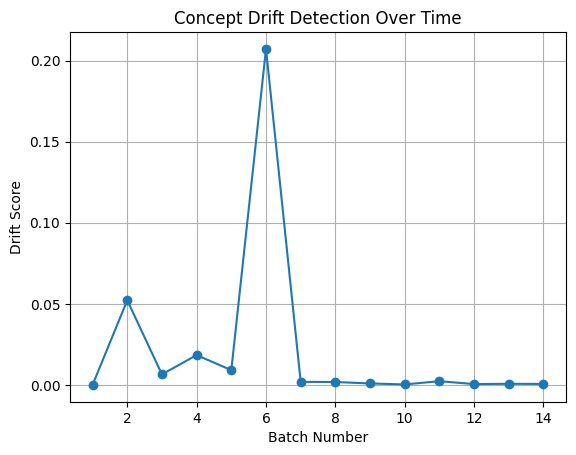

In [12]:
plt.figure()
plt.plot(batches, drift_scores, marker='o')
plt.xlabel("Batch Number")
plt.ylabel("Drift Score")
plt.title("Concept Drift Detection Over Time")
plt.grid(True)
plt.show()

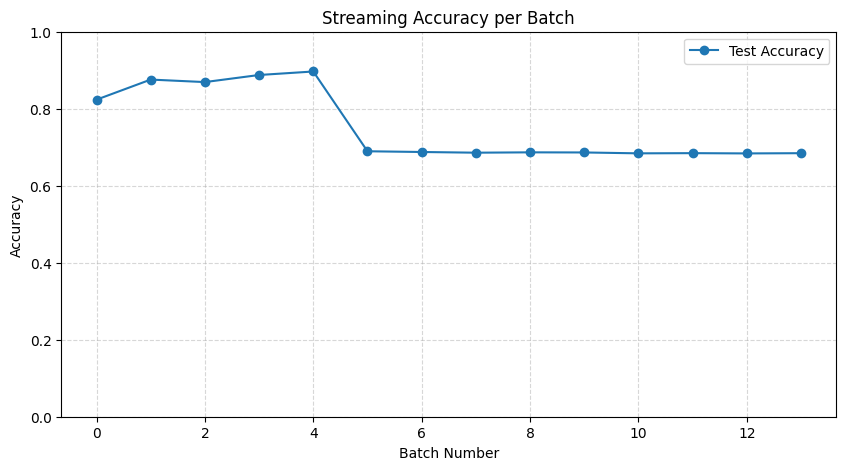

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(acc_log, label="Test Accuracy", marker='o')
plt.title("Streaming Accuracy per Batch")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.ylim(0, 1)  # Accuracy is between 0 and 1
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


In [14]:
from sklearn.metrics import classification_report, f1_score

# Ensure predictions are generated once using the correct input for image_model
X_test_image_scaled = scaler_image.transform(X_test.reshape(len(X_test), -1))
y_pred = image_model.predict(X_test_image_scaled)

print(classification_report(y_test, y_pred, digits=4, zero_division=0))

print("Macro F1:", round(f1_score(y_test, y_pred, average="macro"), 4))
print("Weighted F1:", round(f1_score(y_test, y_pred, average="weighted"), 4))

              precision    recall  f1-score   support

           0     0.6724    0.9510    0.7878       980
           1     0.6079    0.9930    0.7541      1135
           2     0.9121    0.7238    0.8071      1032
           3     0.7129    0.7990    0.7535      1010
           4     0.6520    0.8279    0.7295       982
           5     0.9193    0.3957    0.5533       892
           6     0.8513    0.8309    0.8410       958
           7     0.5615    0.8969    0.6906      1028
           8     0.9032    0.5554    0.6879       974
           9     1.0000    0.0020    0.0040      1009

    accuracy                         0.7040     10000
   macro avg     0.7793    0.6976    0.6609     10000
weighted avg     0.7752    0.7040    0.6621     10000

Macro F1: 0.6609
Weighted F1: 0.6621


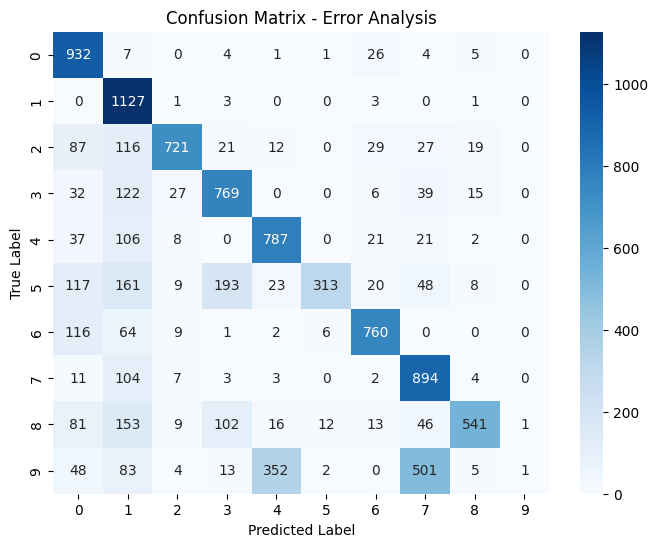

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions
y_pred = multi_model.predict(X_test_multi)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Error Analysis")
plt.show()

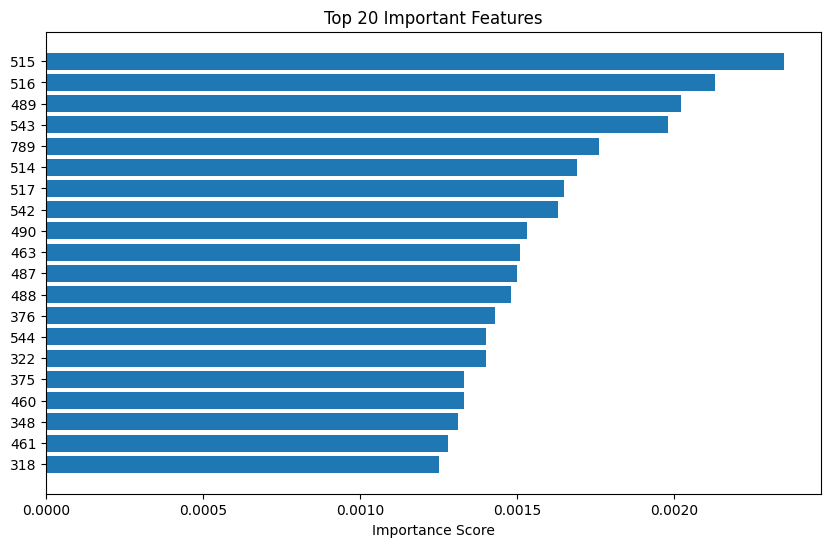

In [16]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    multi_model,
    X_test_multi,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance = result.importances_mean

# Top 20 features
indices = importance.argsort()[-20:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), indices)
plt.xlabel("Importance Score")
plt.title("Top 20 Important Features")
plt.show()

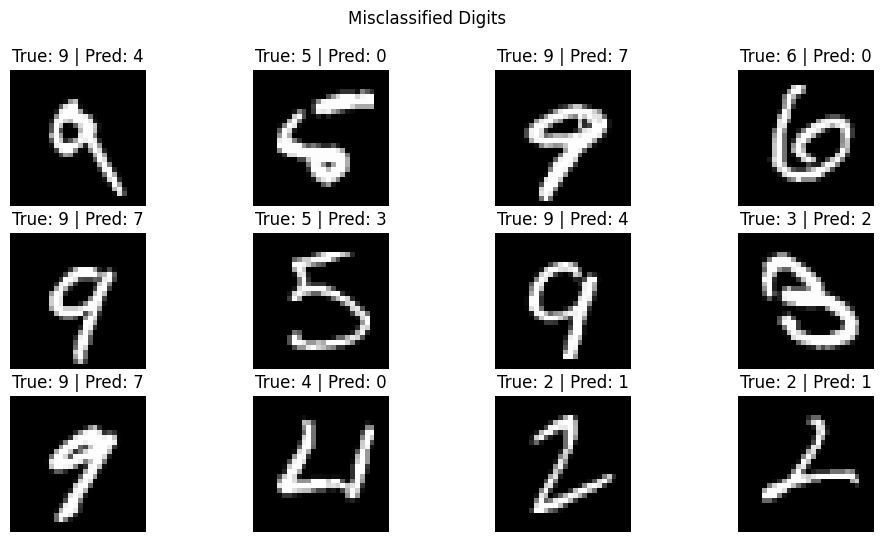

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Find incorrect predictions
misclassified = np.where(y_pred != y_test)[0]

# Number of images to show
n = 12

plt.figure(figsize=(12,6))

for i, idx in enumerate(misclassified[:n]):

    plt.subplot(3,4,i+1)
    plt.imshow(X_test[idx], cmap="gray")

    plt.title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}")

    plt.axis("off")

plt.suptitle("Misclassified Digits")
plt.show()

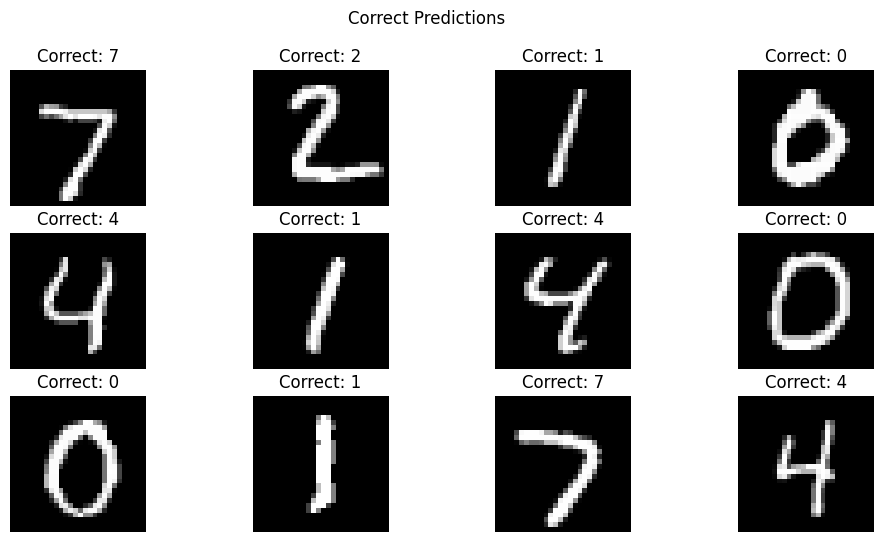

In [18]:
correct = np.where(y_pred == y_test)[0]

plt.figure(figsize=(12,6))

for i, idx in enumerate(correct[:12]):

    plt.subplot(3,4,i+1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"Correct: {y_test[idx]}")
    plt.axis("off")

plt.suptitle("Correct Predictions")
plt.show()

In [19]:
!pip install river

In [20]:
from river.drift import ADWIN

adwin = ADWIN()

detected_batches = []

for i, acc in enumerate(acc_log):

    adwin.update(acc)

    if adwin.drift_detected:
        print("Concept drift detected at batch", i+1)
        detected_batches.append(i+1)

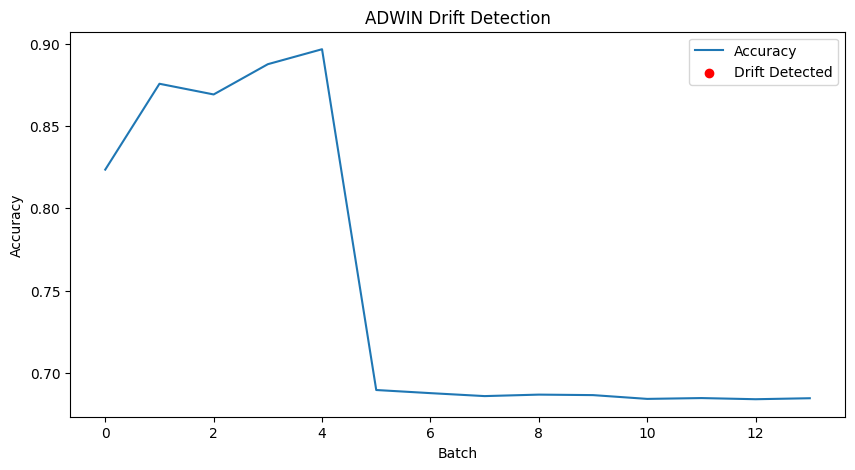

In [21]:
plt.figure(figsize=(10,5))
plt.plot(acc_log, label="Accuracy")
plt.scatter(
    [b-1 for b in detected_batches],
    [acc_log[b-1] for b in detected_batches],
    color="red",
    label="Drift Detected"
)

plt.title("ADWIN Drift Detection")
plt.xlabel("Batch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

svm_model = SVC(kernel="rbf")

rf_model.fit(X_train_multi, y_train)
svm_model.fit(X_train_multi, y_train)

SVC()

In [24]:
rf_pred = rf_model.predict(X_test_multi)
svm_pred = svm_model.predict(X_test_multi)
sgd_pred = multi_model.predict(X_test_multi)

rf_acc = accuracy_score(y_test, rf_pred)
svm_acc = accuracy_score(y_test, svm_pred)
sgd_acc = accuracy_score(y_test, sgd_pred)

print("SGD Accuracy:", sgd_acc)
print("Random Forest Accuracy:", rf_acc)
print("SVM Accuracy:", svm_acc)

SGD Accuracy: 0.6845
Random Forest Accuracy: 0.9662
SVM Accuracy: 0.9633


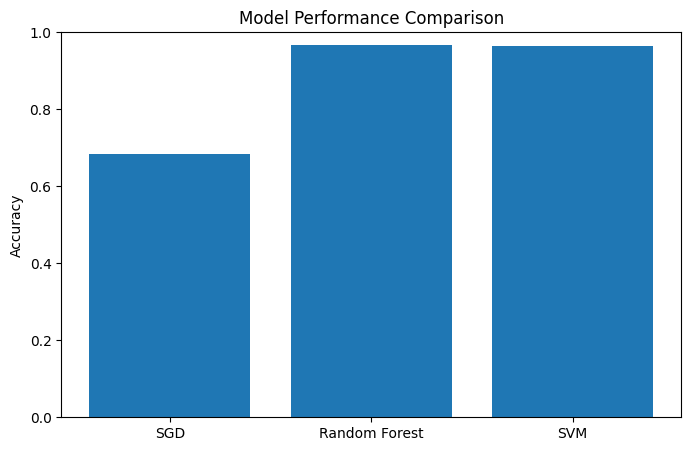

In [25]:
models = ["SGD", "Random Forest", "SVM"]
scores = [sgd_acc, rf_acc, svm_acc]

plt.figure(figsize=(8,5))
plt.bar(models, scores)

plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

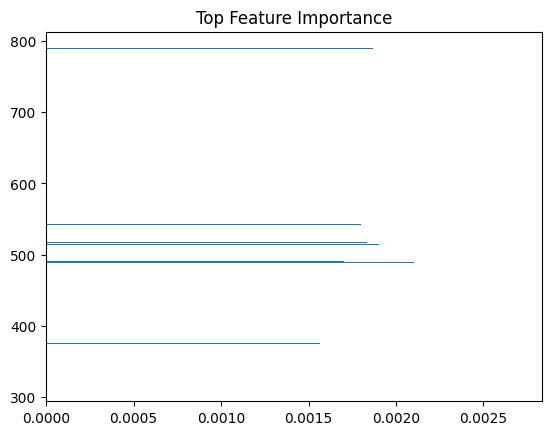

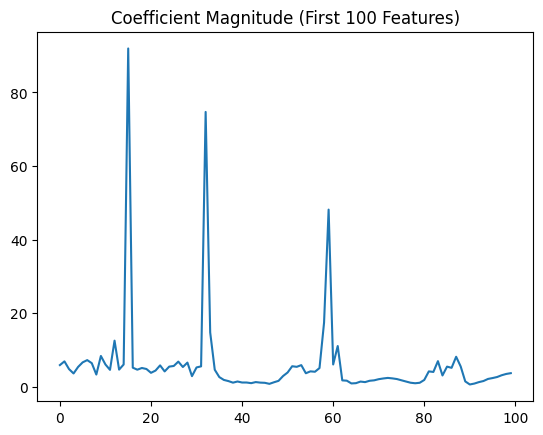

In [26]:
result = permutation_importance(
    multi_model,
    scaler_multi.transform(X_test_multi),
    y_test,
    n_repeats=3,
    random_state=42
)

top_features = np.argsort(result.importances_mean)[-15:]

plt.barh(top_features, result.importances_mean[top_features])
plt.title("Top Feature Importance")
plt.show()

# Coefficient magnitude
coef_magnitude = np.mean(np.abs(multi_model.coef_), axis=0)

plt.plot(coef_magnitude[:100])
plt.title("Coefficient Magnitude (First 100 Features)")
plt.show()


In [29]:
rf = RandomForestClassifier(n_estimators=50)
# Use the already prepared and scaled X_train_multi
rf.fit(X_train_multi, y_train)

sgd_proba = multi_model.predict_proba(
    X_test_multi # X_test_multi is already scaled
)
rf_proba = rf.predict_proba(
    X_test_multi # X_test_multi is already scaled
)

ensemble_proba = (sgd_proba + rf_proba) / 2
ensemble_pred = np.argmax(ensemble_proba, axis=1)

print("Ensemble Accuracy:",
      accuracy_score(y_test, ensemble_pred))


Ensemble Accuracy: 0.9611


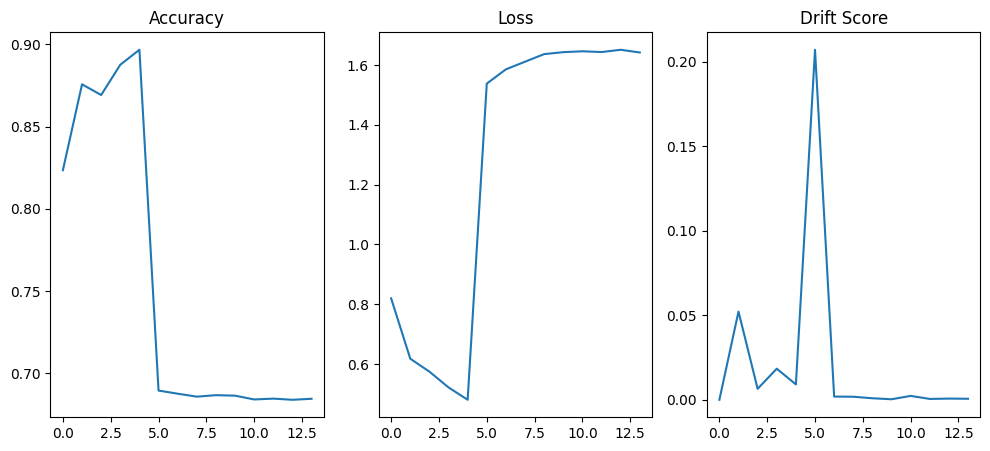

In [30]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.plot(acc_log)
plt.title("Accuracy")

plt.subplot(1,3,2)
plt.plot(loss_log)
plt.title("Loss")

plt.subplot(1,3,3)
plt.plot(drift_scores)
plt.title("Drift Score")

plt.show()

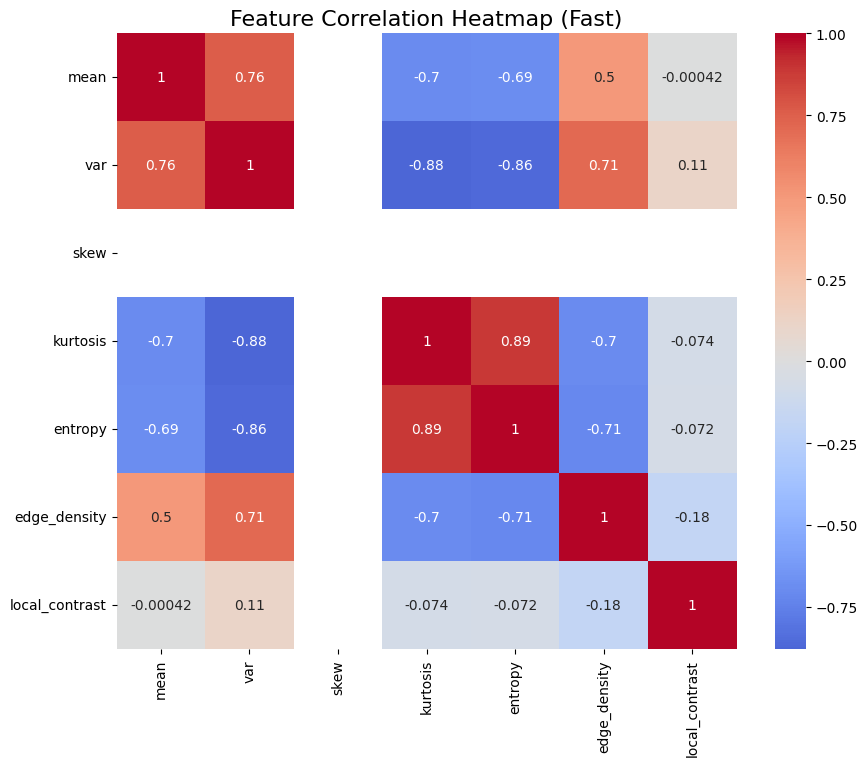

In [32]:
X_train_processed = X_train_multi

stats_df = pd.DataFrame(
    X_train_processed[:, -7:],  # select last 7 features: mean, var, skew, kurt, entropy, edge_density, local_contrast
    columns=["mean","var","skew","kurtosis","entropy","edge_density","local_contrast"]
)

plt.figure(figsize=(10,8))
sns.heatmap(stats_df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap (Fast)", fontsize=16)
plt.show()


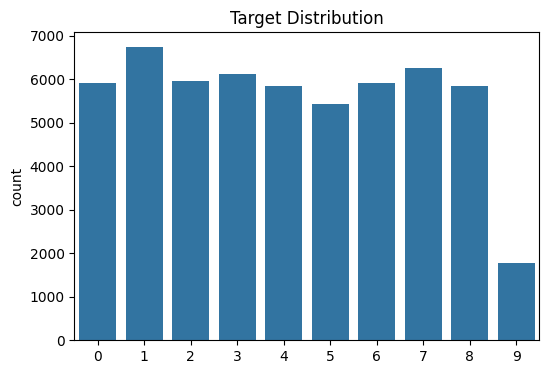

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Target Distribution")
plt.show()


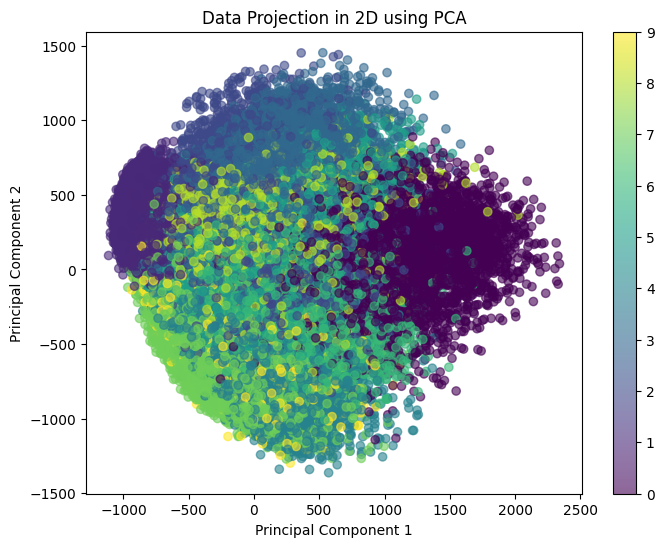

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
# Reshape X_train from (num_samples, height, width) to (num_samples, height * width)
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_pca = pca.fit_transform(X_train_reshaped)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap="viridis", alpha=0.6)
plt.title("Data Projection in 2D using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar()
plt.show()

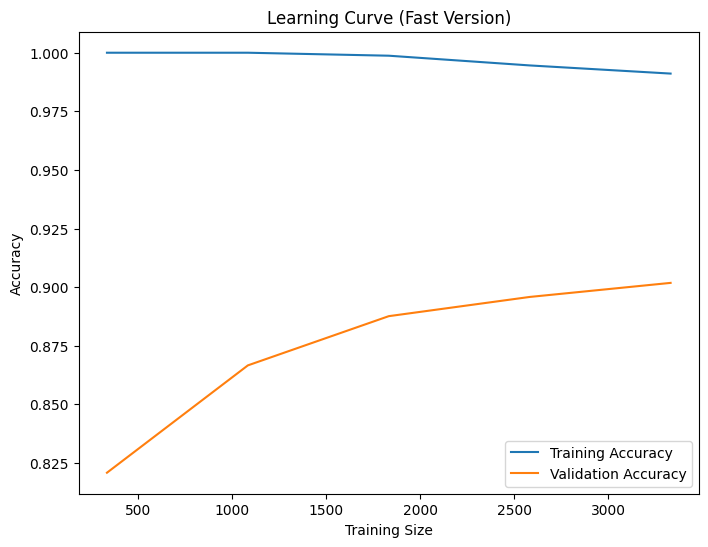

In [36]:
from sklearn.model_selection import learning_curve
import numpy as np

# Sample a smaller dataset to speed up learning curve
sample_idx = np.random.choice(len(X_train), 5000, replace=False)
X_sample_features, _, _ = prepare_multimodal(X_train[sample_idx], scaler_multi_flat, scaler_multi_stats)
X_sample = scaler_multi.transform(X_sample_features)
y_sample = y_train[sample_idx]

train_sizes, train_scores, test_scores = learning_curve(
    multi_model, X_sample, y_sample, cv=3, scoring='accuracy', train_sizes=np.linspace(0.1,1.0,5)
)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Accuracy")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Validation Accuracy")
plt.title("Learning Curve (Fast Version)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

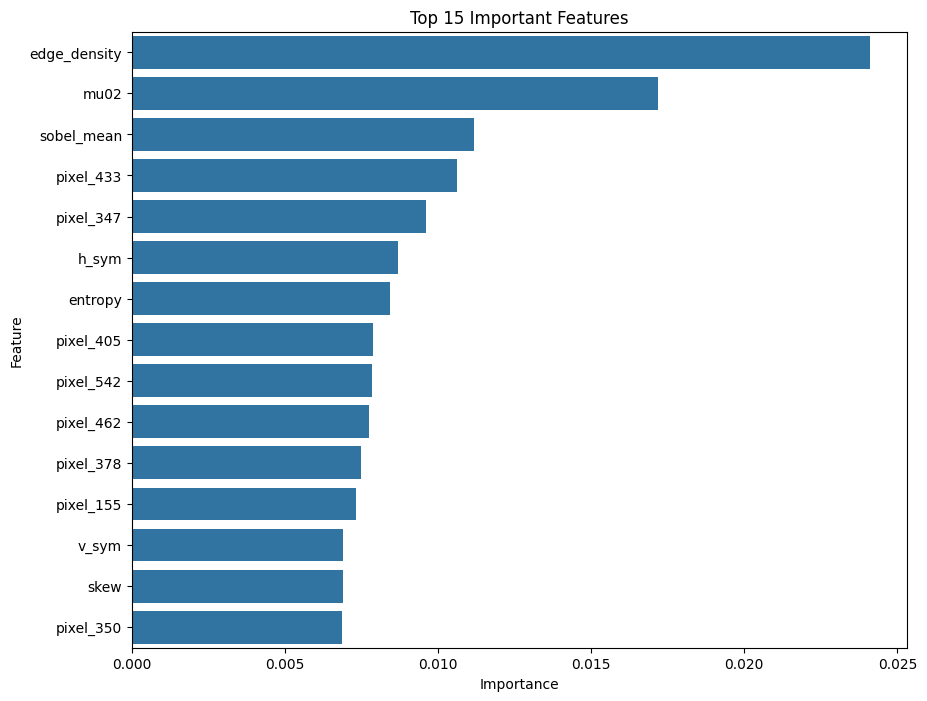

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'rf' (RandomForestClassifier) is the model for which feature importances are desired,
# and it has been fitted in a previous cell (aaFgxeZGEq89).
# The 'rf' model was fitted on features generated by prepare_multimodal, which combines
# 28*28 pixel features with 7 advanced features.

importances = rf.feature_importances_

# Generate feature names:
# 784 pixel features (28*28) + 13 advanced features
pixel_features = [f"pixel_{i}" for i in range(28*28)]
advanced_features = [
    "mean","var","skew","kurtosis","entropy","edge_density","local_contrast",
    "sobel_mean", "sobel_std", "h_sym", "v_sym", "mu20", "mu02"
]
feature_names = pixel_features + advanced_features

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x="Importance", y="Feature", data=feat_df.head(15))
plt.title("Top 15 Important Features")
plt.show()

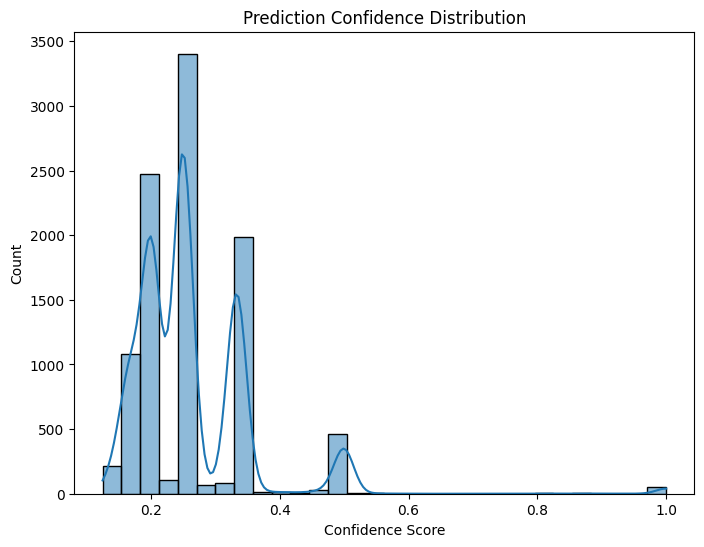

In [38]:
confidence = np.max(y_proba, axis=1)

plt.figure(figsize=(8,6))
sns.histplot(confidence, bins=30, kde=True)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence Score")
plt.show()


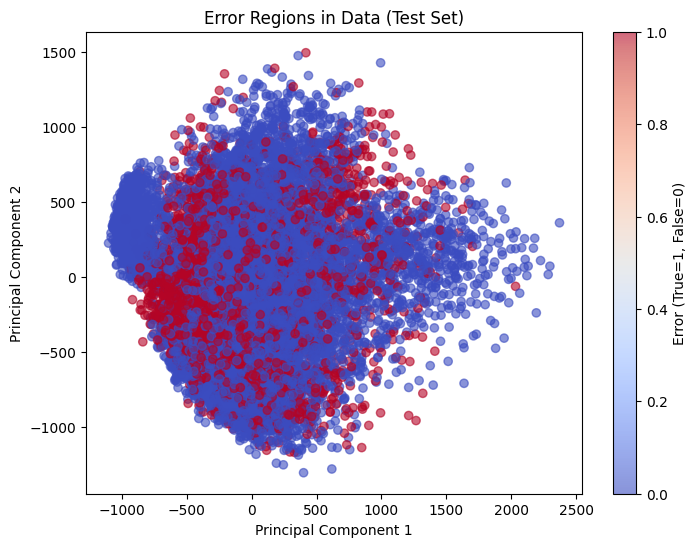

In [40]:
errors = y_pred != y_test

# Create a PCA projection for the test data
X_test_reshaped = X_test.reshape(X_test.shape[0], -1)
X_test_pca = pca.transform(X_test_reshaped) # Use the existing pca fitted on X_train

plt.figure(figsize=(8,6))
plt.scatter(X_test_pca[:,0], X_test_pca[:,1], c=errors, cmap="coolwarm", alpha=0.6)
plt.title("Error Regions in Data (Test Set)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Error (True=1, False=0)")
plt.show()

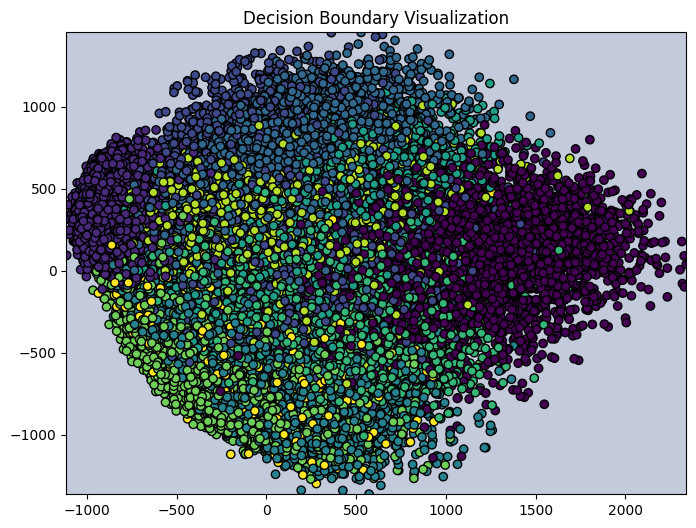

In [42]:
import numpy as np

x_min, x_max = X_pca[:,0].min() - 1, X_pca[:,0].max() + 1
y_min, y_max = X_pca[:,1].min() - 1, X_pca[:,1].max() + 1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Reconstruct pixel data from 2D PCA space
reconstructed_pixels = pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
# Reshape to image format (expected by prepare_multimodal)
reconstructed_images = reconstructed_pixels.reshape(-1, 28, 28)
# Prepare multimodal features and scale them as the model expects
multimodal_features_array, _, _ = prepare_multimodal(reconstructed_images, scaler_multi_flat, scaler_multi_stats)
scaled_multimodal_features = scaler_multi.transform(multimodal_features_array)

# Use multi_model for prediction
Z = multi_model.predict(scaled_multimodal_features)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, edgecolor='k')
plt.title("Decision Boundary Visualization")
plt.show()

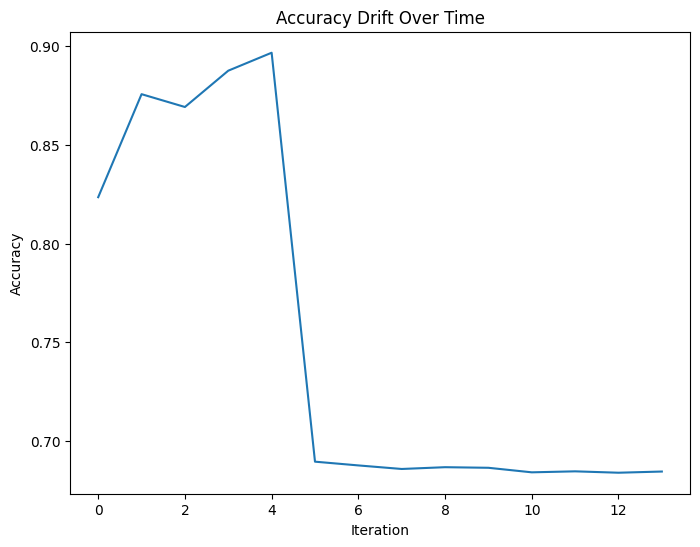

In [43]:
plt.figure(figsize=(8,6))
plt.plot(acc_log)
plt.title("Accuracy Drift Over Time")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.show()


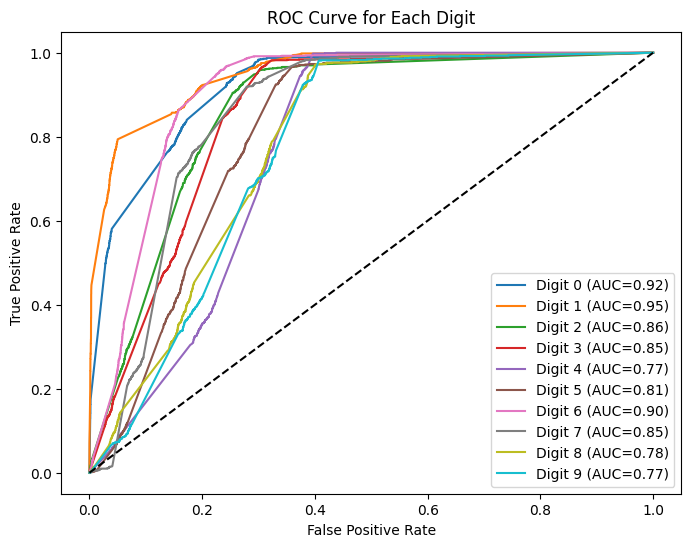

In [44]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=np.arange(10))

# Get probabilities
y_score = multi_model.predict_proba(X_test_multi)

plt.figure(figsize=(8,6))

for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Digit {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Each Digit")
plt.legend()
plt.show()

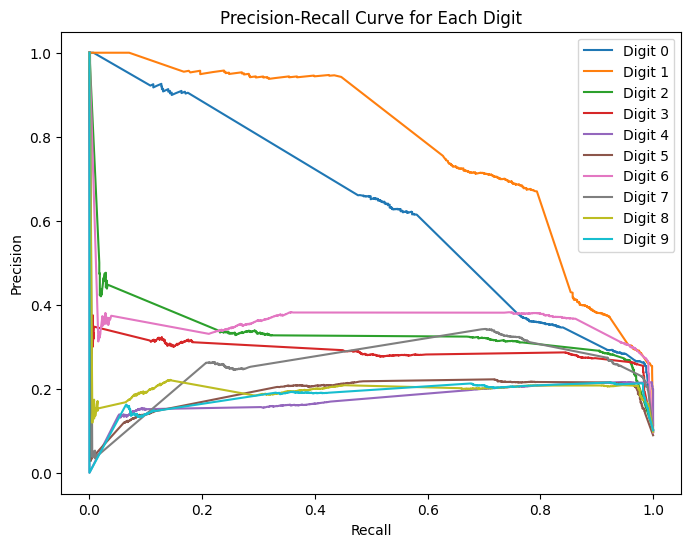

In [45]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for i in range(10):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    plt.plot(recall, precision, label=f"Digit {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Each Digit")
plt.legend()
plt.show()

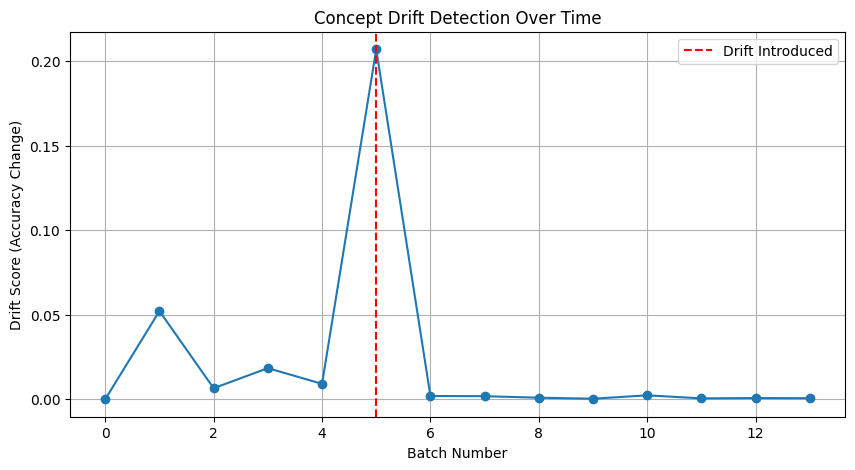

In [46]:
plt.figure(figsize=(10,5))

plt.plot(drift_scores, marker='o')
plt.axvline(x=5, color='red', linestyle='--', label="Drift Introduced")

plt.title("Concept Drift Detection Over Time")
plt.xlabel("Batch Number")
plt.ylabel("Drift Score (Accuracy Change)")
plt.legend()
plt.grid(True)
plt.show()

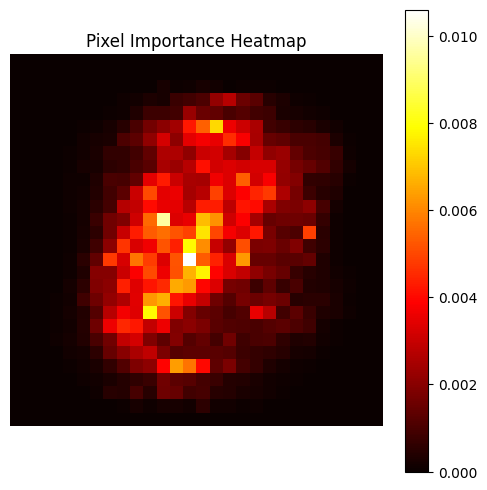

In [47]:
# Get pixel importances only (first 784 features)
pixel_importance = importances[:784]

# Reshape into 28x28 image
importance_img = pixel_importance.reshape(28,28)

plt.figure(figsize=(6,6))
plt.imshow(importance_img, cmap="hot")
plt.colorbar()
plt.title("Pixel Importance Heatmap")
plt.axis("off")
plt.show()

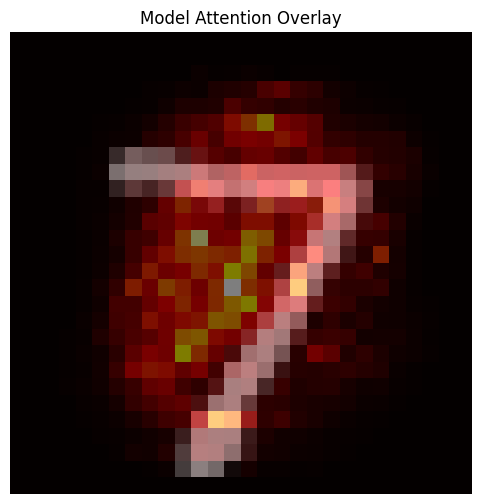

In [48]:
sample = X_test[0]

plt.figure(figsize=(6,6))
plt.imshow(sample, cmap="gray")
plt.imshow(importance_img, cmap="hot", alpha=0.5)
plt.title("Model Attention Overlay")
plt.axis("off")
plt.show()

In [50]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess data
# Normalize pixel values to [0,1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Add channel dimension (needed for Conv2D)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes for digits 0-9
])

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=64,
                    validation_split=0.1)

# Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.8744 - loss: 0.4156 - val_accuracy: 0.9858 - val_loss: 0.0529
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 50s 59ms/step - accuracy: 0.9832 - loss: 0.0553 - val_accuracy: 0.9895 - val_loss: 0.0385
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.9891 - loss: 0.0352 - val_accuracy: 0.9880 - val_loss: 0.0396
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.9907 - loss: 0.0284 - val_accuracy: 0.9903 - val_loss: 0.0331
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9933 - loss: 0.0211 - val_accuracy: 0.9908 - val_loss: 0.0335
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 56ms/step - accuracy: 0.9945 - loss: 0.0190 - val_accuracy: 0.9892 - val_loss: 0.0432
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.9950 - loss: 0.0149 - val_accuracy: 0.9875 - val_loss: 0.0481
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - accuracy: 0.9963 - loss: 0.0111 - 

In [52]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create a data generator with validation split defined in the constructor
datagen_train = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.1 # Specify validation split here
)

# Fit the generator on the training data
datagen_train.fit(X_train)

# Create training and validation data generators
train_generator = datagen_train.flow(X_train, y_train, batch_size=64, subset='training')
validation_generator = datagen_train.flow(X_train, y_train, batch_size=64, subset='validation')

# Train model using the generators
history = model.fit(train_generator,
                    epochs=20,
                    validation_data=validation_generator) # Pass validation_data as a separate generator

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 95ms/step - accuracy: 0.9672 - loss: 0.1154 - val_accuracy: 0.9857 - val_loss: 0.0525
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 69s 82ms/step - accuracy: 0.9843 - loss: 0.0475 - val_accuracy: 0.9873 - val_loss: 0.0452
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 64s 75ms/step - accuracy: 0.9876 - loss: 0.0394 - val_accuracy: 0.9897 - val_loss: 0.0324
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 66s 78ms/step - accuracy: 0.9894 - loss: 0.0334 - val_accuracy: 0.9912 - val_loss: 0.0303
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 67s 80ms/step - accuracy: 0.9899 - loss: 0.0317 - val_accuracy: 0.9918 - val_loss: 0.0313
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 66s 78ms/step - accuracy: 0.9908 - loss: 0.0300 - val_accuracy: 0.9887 - val_loss: 0.0367
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 77ms/step - accuracy: 0.9917 - loss: 0.0258 - val_accuracy: 0.9900 - val_loss: 0.0325
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 63s 75ms/step - accuracy: 0.9918 - loss: 0.0255 - 

In [53]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9918 - loss: 0.0281
Test Loss: 0.0192
Test Accuracy: 99.45%


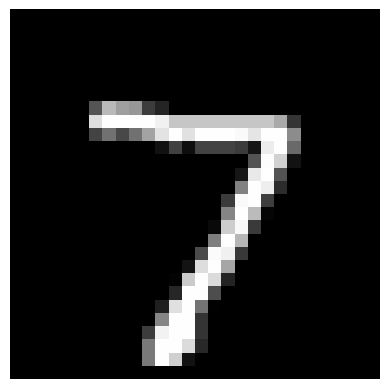

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Predicted: 7, Actual: 7


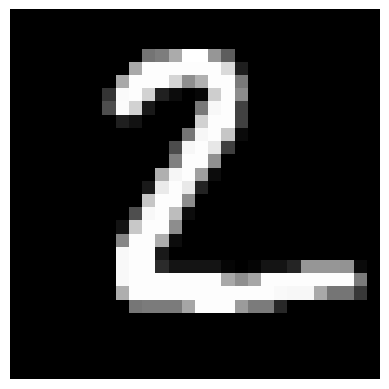

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted: 2, Actual: 2


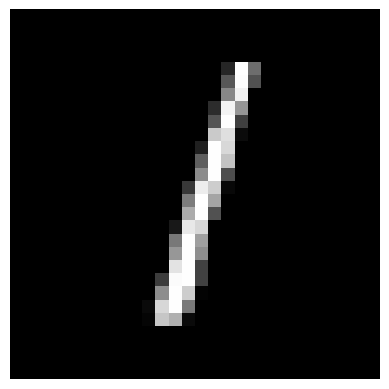

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted: 1, Actual: 1


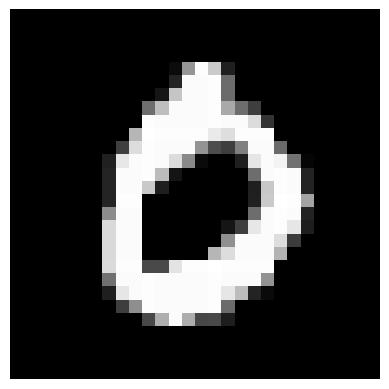

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted: 0, Actual: 0


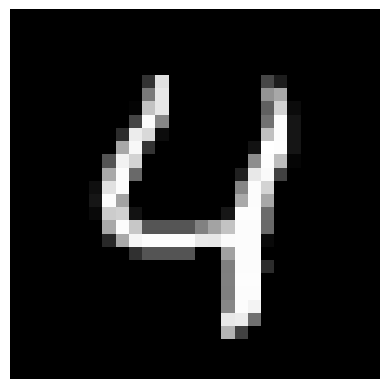

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted: 4, Actual: 4


In [54]:
import matplotlib.pyplot as plt

for i in range(5):  # first 5 test images
    img = X_test[i].reshape(28,28)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

    pred = model.predict(X_test[i].reshape(1,28,28,1))
    print(f"Predicted: {np.argmax(pred)}, Actual: {np.argmax(y_test[i])}")

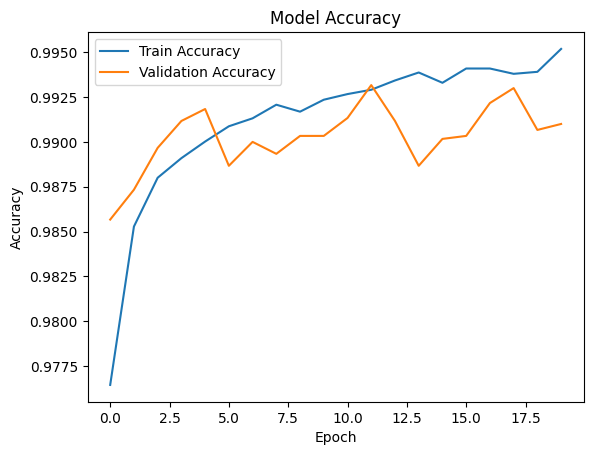

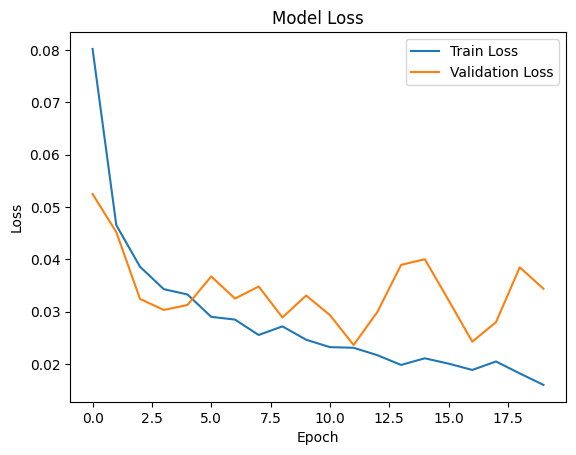

In [55]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


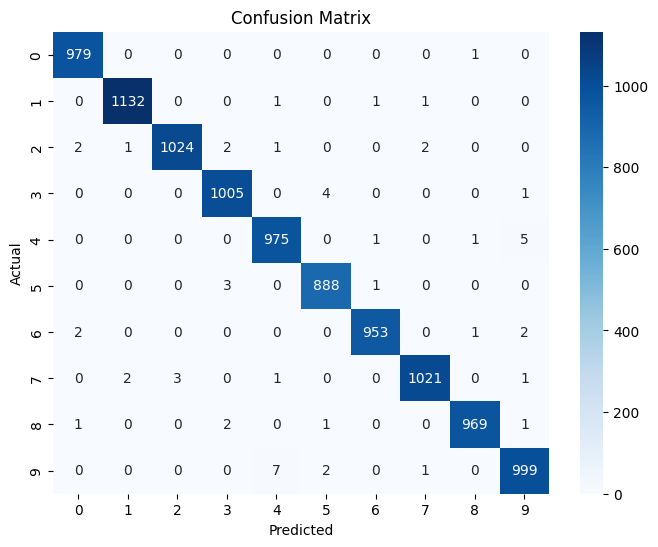

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Predict classes on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


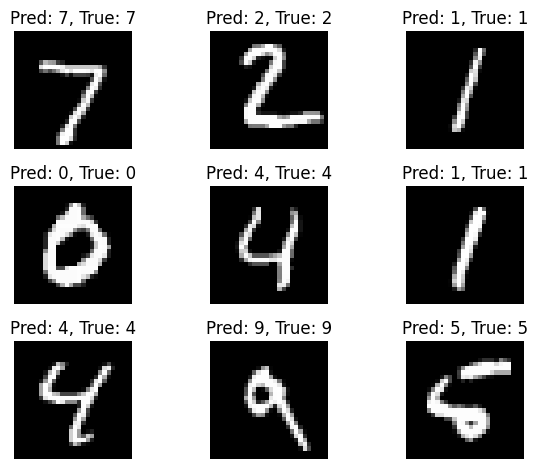

In [57]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    pred_label = np.argmax(model.predict(X_test[i].reshape(1,28,28,1)))
    true_label = np.argmax(y_test[i])
    plt.title(f"Pred: {pred_label}, True: {true_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

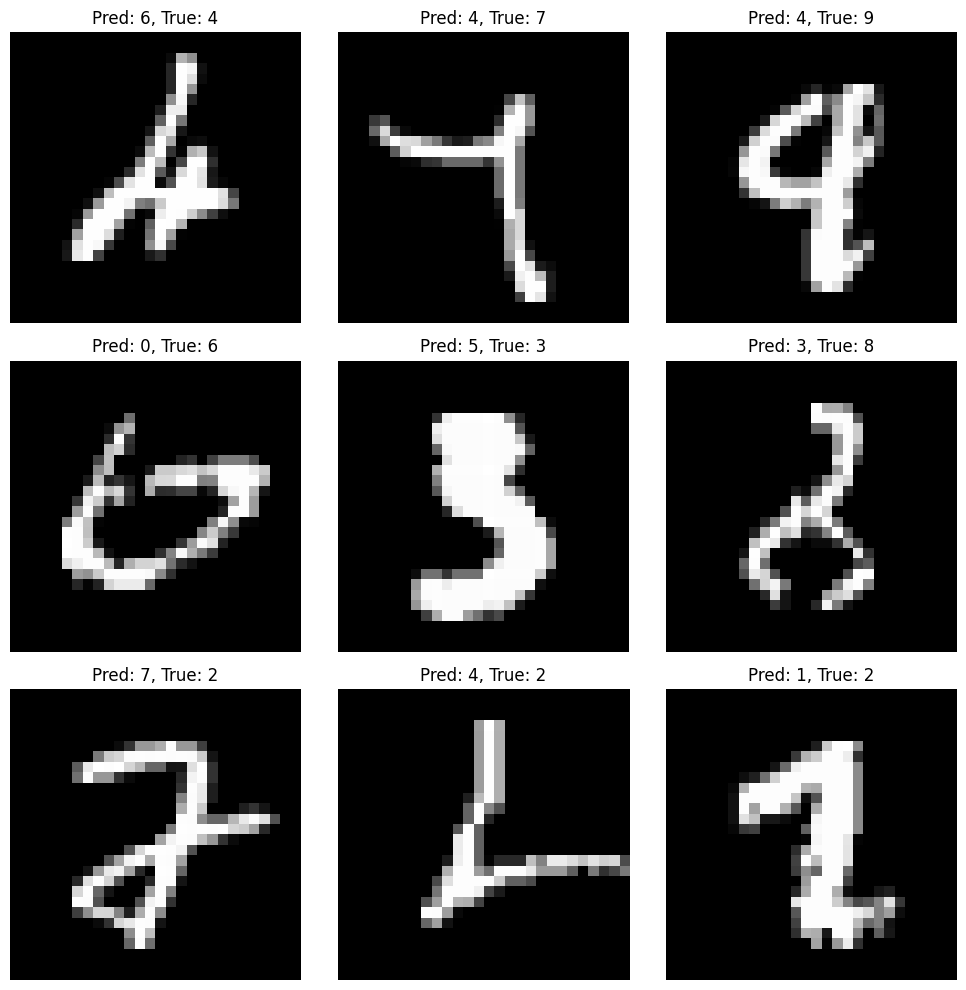

In [58]:
misclassified_idx = np.where(y_pred_classes != y_true)[0]

plt.figure(figsize=(10,10))
for i, idx in enumerate(misclassified_idx[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred_classes[idx]}, True: {y_true[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()